<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_01_Foundations/Week_02_Data_Analytics/Day_10_End_to_End_toy_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("/content/placement_toy_dataset.csv")

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


### frame the prob
1. preprocess + EDA + Feature selection
2. Extracting i/p + o/p
3. Scale the values -> from sklearn.preprocessing StandardScaler ->fit_transform(Only for X_train and X_Test)
4. train test split -> from sklearn.model_selection
5. train the model
6. Eval the model + model selection
7. Deploy the model

### Preprocessing - Removal of first col

In [8]:
df_upd = df.iloc[:,1:]

In [9]:
df_upd.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

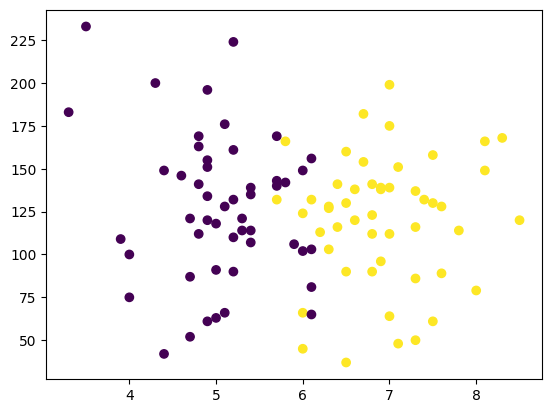

In [15]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

i/p and o/p -> independent and dependent

In [26]:
x = df_upd.iloc[:,:2]
y = df_upd.iloc[:,2:]

In [22]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [27]:
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size=0.1)


In [30]:
X_train

,cgpa,iq
59,4.8,112.0
37,8.1,149.0
66,6.9,96.0
28,5.2,90.0
81,5.4,107.0
...,...,...
12,5.4,139.0
94,4.7,52.0
6,5.7,143.0
34,4.8,163.0


In [31]:
X_test

,cgpa,iq
68,4.0,75.0
86,5.1,128.0
97,6.7,182.0
33,6.0,149.0
13,6.4,116.0
62,6.0,102.0
23,4.7,87.0
54,6.4,141.0
75,4.8,169.0
78,6.1,81.0


In [32]:
Y_test

,placement
68,0
86,0
97,1
33,0
13,1
62,0
23,0
54,1
75,0
78,0


In [33]:
Y_train

,placement
59,0
37,1
66,1
28,0
81,0
...,...
12,0
94,0
6,0
34,0


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [38]:
X_train_up = scaler.fit_transform(X_train)

In [39]:
X_train_up

array([[-1.06431658, -0.28962793],
       [ 1.78601727,  0.63065929],
       [ 0.74953223, -0.68758997],
       [-0.71882157, -0.83682573],
       [-0.54607406, -0.41399107],
       [ 0.92227974,  0.68040454],
       [-1.15069033, -0.06577428],
       [-0.97794283, -1.55813193],
       [-1.40981159, -2.03071185],
       [ 1.26777475,  0.85451293],
       [-0.1142053 , -0.43886369],
       [-0.71882157, -0.33937318],
       [ 1.09502725, -1.83173083],
       [-0.80519532,  1.30222023],
       [ 0.05854221, -0.51348158],
       [ 1.35414851,  0.10833411],
       [-0.71882157,  0.92913082],
       [-0.20057905,  1.05349395],
       [ 0.83590599, -1.48351405],
       [ 1.95876478,  1.10323921],
       [ 0.40403722,  0.15807937],
       [-0.71882157,  2.49610635],
       [ 0.23128972,  0.10833411],
       [ 0.74953223,  0.38193301],
       [ 0.74953223,  0.35706039],
       [-0.71882157,  0.20782462],
       [ 0.05854221,  0.20782462],
       [ 1.09502725, -0.19013742],
       [-0.97794283,

In [41]:
X_test_up = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [43]:
# MODEL TRAINING
clf.fit(X_train_up,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [48]:
y_pred = clf.predict(X_test_up)

In [46]:
Y_test

,placement
68,0
86,0
97,1
33,0
13,1
62,0
23,0
54,1
75,0
78,0


In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.7

<Axes: >

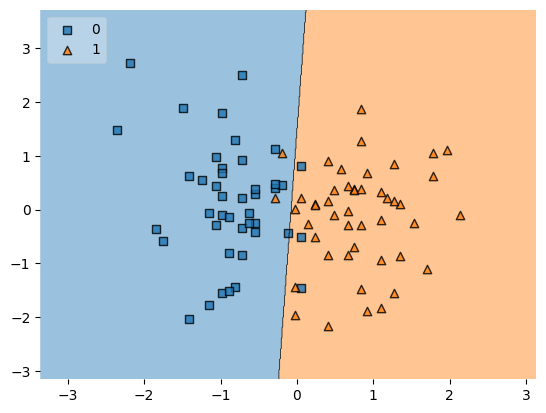

In [60]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train_up,Y_train.values.reshape(90,),
                                clf=clf, legend=2)

In [61]:
import pickle

In [62]:
pickle.dump(clf,open('model.pkl','wb'))